# CARMA(4,3) pseudo-QMLE and L?vy increments

This notebook estimates the L?vy drift rate $m$ and variance rate $\nu^2$ for a CARMA model whose AR and MA coefficients $(a,b)$ are fixed by the ACF calibration in `02order.ipynb`.

The continuous-time model is
$$
    dX_t = A X_t\,dt + e_p\,dL_t, \qquad Y_t = b^\top X_t,
$$
with
$$
    \mathbb E[dL_t] = m\,dt, \qquad \mathrm{Var}(dL_t)=\nu^2\,dt.
$$
Only $(m,\nu^2)$ are estimated here. The likelihood is therefore a reduced Gaussian pseudo-likelihood conditional on the selected $(a,b)$, not a global optimisation over all CARMA parameters.

Sections:

| Section | Purpose |
|---|---|
| 1 | Build the CARMA state-space model from the selected roots and coefficients |
| 2 | Estimate $m$ and $\nu^2$ by prediction-error QMLE |
| 3 | Check standardized innovations |
| 4 | Save the QMLE result |
| 5 | Recover a L?vy increment path from the smoothed state estimate |
| Tests | Verify indexing, Van Loan covariance, simulation recovery, and L?vy recovery |


In [ ]:
%matplotlib inline
from pathlib import Path
import json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import expm, solve_continuous_lyapunov
from scipy.stats import norm as norm_dist

plt.rcParams.update({'font.size': 10, 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})

CWD = Path.cwd().resolve()
if (CWD / 'data' / 'seasonality' / 'french_panel.csv').exists():
    CODE = CWD
elif (CWD.parent / 'data' / 'seasonality' / 'french_panel.csv').exists():
    CODE = CWD.parent
else:
    raise FileNotFoundError(
        f"Could not locate project data directory from cwd={CWD}. "
        "Run this notebook from the repo root or from notebooks/."
    )
DATA = CODE / 'data'
OUT  = DATA / 'kalman'
OUT.mkdir(parents=True, exist_ok=True)

pr = pd.read_csv(DATA / 'seasonality' / 'french_panel.csv',
                 index_col=0)['log_price_resid'].to_numpy(float)
pr = pr[np.isfinite(pr)]
N  = len(pr)
v0 = float(pr @ pr / N)
print(f'{N:,} hourly deseasonalised log-price residuals')
print(f'  raw variance = {v0:.4e}   raw mean = {pr.mean():.4e}')


## 1. State-space construction

For a CARMA$(p,q)$ process, the AR polynomial is written
$$
    a(z)=z^p+a_1z^{p-1}+\cdots+a_p,
$$
and the MA polynomial is
$$
    b(z)=b_0+b_1z+\cdots+b_qz^q, \qquad q\le p-1.
$$
The JSON file stores `ar_coefficients = [a_1,\ldots,a_p]` and `b_coefficients = [b_0,\ldots,b_q]`. The observation vector is padded to length $p$ when $q<p-1$.

The companion matrix follows Brockwell--Lindner's convention:
$$
A=
\begin{pmatrix}
0&1&0&\cdots&0\\
0&0&1&\cdots&0\\
\vdots&&&\ddots&1\\
-a_p&-a_{p-1}&\cdots&-a_2&-a_1
\end{pmatrix},
\qquad e_p=(0,\ldots,0,1)^\top.
$$
If all roots of $a$ have negative real parts, the stationary covariance for unit L?vy variance solves
$$
    A\Pi_1+\Pi_1A^\top=-e_pe_p^\top.
$$
For hourly sampling $\Delta=1$, the exact discrete transition is
$$
    X_{i+1}=F X_i + m g + \eta_i,
    \qquad F=e^{A\Delta},
$$
where
$$
    g=\int_0^\Delta e^{Au}e_p\,du,
    \qquad \eta_i\sim(0,\nu^2 Q_{\rm base}),
$$
and
$$
    Q_{\rm base}=\int_0^\Delta e^{Au}e_pe_p^\top e^{A^\top u}\,du.
$$
The integral is evaluated by the Van Loan block exponential.


In [ ]:
def build_companion_matrix(ar_coefficients):
    """Companion matrix for a(z)=z^p+a_1 z^{p-1}+...+a_p."""
    ar = np.asarray(ar_coefficients, dtype=float)
    p  = len(ar)
    A  = np.zeros((p, p))
    A[0:p-1, 1:p] = np.eye(p - 1)
    A[p - 1, :]   = -ar[::-1]

    poly_check = np.poly(np.linalg.eigvals(A)).real
    expected   = np.concatenate([[1.0], ar])
    if not np.allclose(poly_check, expected, atol=1e-6):
        raise ValueError(
            f"Companion matrix check FAILED.\n"
            f"  poly from eigvals : {poly_check}\n"
            f"  expected          : {expected}"
        )
    return A


def build_b_vector(b_coefficients, p):
    """Observation vector for Y_t=b^T X_t, right-padded when q<p-1."""
    b = np.asarray(b_coefficients, dtype=float)
    q = len(b) - 1
    if q > p - 1:
        raise ValueError(f"q={q} must be <= p-1={p-1}  (CARMA identifiability condition)")
    n_pad = p - 1 - q
    b_vec = np.concatenate([b, np.zeros(n_pad)]) if n_pad > 0 else b.copy()
    assert len(b_vec) == p
    return b_vec


def compute_Pi1_and_Qbase(A, e_p, Delta):
    """Stationary covariance and exact sampled process noise for nu^2=1."""
    p = len(e_p)
    M = np.outer(e_p, e_p)

    Pi1 = solve_continuous_lyapunov(A, -M)

    Block = np.zeros((2 * p, 2 * p))
    Block[0:p,   0:p]   = -A
    Block[0:p,   p:2*p] =  M
    Block[p:2*p, p:2*p] =  A.T
    Phi    = expm(Block * Delta)
    Q_base = Phi[p:2*p, p:2*p].T @ Phi[0:p, p:2*p]

    return Pi1, Q_base


def psd_sqrt(M, tol=1e-12):
    """Symmetric square root of a numerical PSD matrix."""
    M = 0.5 * (M + M.T)
    vals, vecs = np.linalg.eigh(M)
    if vals.min() < -tol:
        raise ValueError(f"Matrix is not positive semidefinite; min eig={vals.min():.3e}")
    return vecs @ np.diag(np.sqrt(np.clip(vals, 0.0, None)))


def simulate_sampled_carma(A, b_vec, F, Q_base, Pi1, e_p, m, nu2, n,
                           Delta=1.0, burnin=0, seed=None, stationary_init=True):
    """Exact sampled Gaussian CARMA simulation for fixed (A,b)."""
    rng = np.random.default_rng(seed)
    p = A.shape[0]
    total = int(n + burnin)
    if total <= 0:
        raise ValueError("n + burnin must be positive")

    g = np.linalg.solve(A, (F - np.eye(p)) @ e_p)
    q_sqrt = psd_sqrt(Q_base)
    pi_sqrt = psd_sqrt(Pi1)
    shift = np.linalg.solve(-A, e_p)

    if stationary_init:
        x = m * shift + np.sqrt(nu2) * (pi_sqrt @ rng.standard_normal(p))
    else:
        x = np.zeros(p)

    X = np.empty((total, p))
    y = np.empty(total)
    for i in range(total):
        x = F @ x + m * g + np.sqrt(nu2) * (q_sqrt @ rng.standard_normal(p))
        X[i] = x
        y[i] = float(b_vec @ x)

    return y[burnin:], X[burnin:]


with open(OUT / 'price_multiscale_carma_selected.json') as f:
    cfg = json.load(f)

ar_coefficients = np.array(cfg['ar_coefficients'])
b_coefficients  = np.array(cfg['b_coefficients'])
roots           = np.array(cfg['roots'])
p = len(ar_coefficients)
q = len(b_coefficients) - 1
Delta = 1.0

ar = ar_coefficients
b  = b_coefficients

real_parts = roots[:, 0]
if not np.all(real_parts < 0):
    raise ValueError(
        f"Non-causal model: {(real_parts >= 0).sum()} root(s) with Re >= 0.\n"
        f"Roots: {roots[real_parts >= 0]}"
    )
print(f"Causality OK - {p} roots, max Re(root) = {real_parts.max():.6f}")

A     = build_companion_matrix(ar_coefficients)
ep    = np.zeros(p); ep[-1] = 1.0
b_vec = build_b_vector(b_coefficients, p)
F     = expm(A * Delta)
Pi1, Q_base = compute_Pi1_and_Qbase(A, ep, Delta)

dc_gain       = float(b_coefficients[0]) / float(ar_coefficients[-1])
dc_gain_check = float(b_vec @ np.linalg.solve(-A, ep))
assert np.isclose(dc_gain, dc_gain_check, rtol=1e-5), \
    f"DC gain mismatch: b(0)/a(0)={dc_gain:.6e}  vs  b^T(-A)^{{-1}}e_p={dc_gain_check:.6e}"

print(f"CARMA({p},{q})  |  b_vec = {b_vec.round(6)}")
print(f"A eigenvalues  : {np.linalg.eigvals(A).round(5)}")
print(f"Pi1  min eigval: {np.linalg.eigvalsh(Pi1).min():.3e}")
print(f"Qbase min eigval: {np.linalg.eigvalsh(Q_base).min():.3e}")
print(f"DC gain b(0)/a(0) = {dc_gain:.6e}")


## 2. Prediction-error QMLE for $m$ and $\nu^2$

The data are kept raw: no sample mean is removed. The mean is estimated through the L?vy drift $m$.

For fixed $(a,b)$, the Kalman covariance recursion does not depend on $m$ or on the observations. Let $\widehat U_i$ be the one-step state predictor before seeing $Y_i$. With unit L?vy variance, define
$$
    \Omega_i = \Pi_i-\Psi_i,
    \qquad \Delta_i=b^\top\Omega_i b,
    \qquad \theta_i=F\Omega_i b.
$$
The prediction-error recursion is
$$
\begin{aligned}
    e_i &= Y_i-b^\top\widehat U_i,\\
    \Pi_{i+1} &= F\Pi_iF^\top+Q_{\rm base},\\
    \Psi_{i+1} &= F\Psi_iF^\top + {\theta_i\theta_i^\top\over \Delta_i},\\
    \widehat U_{i+1} &= F\widehat U_i + {\theta_i\over\Delta_i}e_i.
\end{aligned}
$$
Initialization is $\widehat U_1=0$, $\Pi_1$ equal to the stationary covariance, and $\Psi_1=0$.

The stationary mean of the observation is
$$
    \mathbb E[Y_t] = m\, b^\top(-A)^{-1}e_p = m\,{b(0)\over a(0)} = m\,{b_0\over a_p}.
$$
Because $(a,b)$ are fixed, the predictor is affine in $m$:
$$
    \widehat Y_i(m)=\widehat Y_i(0)+m c_i.
$$
The coefficient $c_i$ is obtained by filtering a constant series equal to one. If $\widehat c_i$ is the one-step predictor of that constant series, then
$$
    c_i={b_0\over a_p}(1-\widehat c_i).
$$
Thus estimating $m$ is a one-dimensional weighted least-squares problem:
$$
    S(m)=\sum_{i=1}^n{(e_i-mc_i)^2\over\Delta_i},
    \qquad
    \widehat m={\sum_i e_i c_i/\Delta_i\over\sum_i c_i^2/\Delta_i}.
$$
The variance rate and reduced log-likelihood are
$$
    \widehat\nu^2={1\over n}\sum_{i=1}^n{(e_i-\widehat m c_i)^2\over\Delta_i},
$$
$$
    \ell(\widehat m,\widehat\nu^2)
    =-{1\over2}\left[n\log(2\pi\widehat\nu^2)+\sum_i\log\Delta_i+n\right].
$$
The final $+n$ appears because the quadratic term equals $n$ after substituting $\widehat\nu^2$.


In [ ]:
def kalman_filter_fixed_params(A, b_vec, F, Q_base, Pi1, series):
    """Prediction-error Kalman recursion for fixed CARMA parameters."""
    series = np.asarray(series, dtype=float)
    n = len(series)
    p = A.shape[0]

    U_hat = np.zeros(p)
    Pi    = Pi1.copy()
    Psi   = np.zeros((p, p))
    Omega = Pi.copy()

    residuals  = np.empty(n)
    r_array    = np.empty(n)
    Uhat_trace = np.empty((n, p))

    for i in range(n):
        Omega_b = Omega @ b_vec
        Delta   = float(b_vec @ Omega_b)
        if Delta <= 0:
            raise RuntimeError(
                f"Delta[{i + 1}] = {Delta:.6e} <= 0 at step {i + 1}/{n}. "
                "Filter not positive definite — check parameter validity."
            )
        Theta = F @ Omega_b

        resid = series[i] - float(b_vec @ U_hat)
        residuals[i]  = resid
        r_array[i]    = Delta
        Uhat_trace[i] = U_hat.copy()

        Pi_new  = F @ Pi  @ F.T + Q_base
        Psi_new = F @ Psi @ F.T + np.outer(Theta, Theta) / Delta
        Omega   = Pi_new - Psi_new
        Pi      = Pi_new
        Psi     = Psi_new
        U_hat   = F @ U_hat + (Theta / Delta) * resid

    return residuals, r_array, Uhat_trace


def estimate_m_nu2(y, a_coeffs, b_coeffs, Delta=1.0):
    """Reduced Gaussian QMLE for (m, nu^2) with fixed CARMA coefficients."""
    y = np.asarray(y, dtype=float)
    n = len(y)
    p = len(a_coeffs)

    A_loc  = build_companion_matrix(a_coeffs)
    ep_loc = np.zeros(p); ep_loc[-1] = 1.0
    bv_loc = build_b_vector(b_coeffs, p)
    F_loc  = expm(A_loc * Delta)
    Pi1_loc, Qb_loc = compute_Pi1_and_Qbase(A_loc, ep_loc, Delta)

    dc_gain_loc = float(b_coeffs[0]) / float(a_coeffs[-1])

    e, r, _ = kalman_filter_fixed_params(A_loc, bv_loc, F_loc, Qb_loc, Pi1_loc, y)

    residuals_c, _, _ = kalman_filter_fixed_params(
        A_loc, bv_loc, F_loc, Qb_loc, Pi1_loc, np.ones(n)
    )
    coef = dc_gain_loc * residuals_c

    num   = float(np.sum(e * coef / r))
    den   = float(np.sum(coef ** 2 / r))
    m_hat = num / den

    resid_adj = e - m_hat * coef
    nu2_hat   = float(np.sum(resid_adj ** 2 / r) / n)

    loglik = -0.5 * (n * np.log(2.0 * np.pi * nu2_hat) + np.sum(np.log(r)) + n)

    return dict(
        m_hat    = float(m_hat),
        nu2_hat  = float(nu2_hat),
        loglik   = float(loglik),
        r_array  = r,
        residuals= resid_adj,
        e_raw    = e,
        coef     = coef,
    )


result  = estimate_m_nu2(pr, ar_coefficients, b_coefficients, Delta=Delta)
m_hat   = result['m_hat']
nu2_hat = result['nu2_hat']
nu2     = nu2_hat   # alias kept for sections 3 and 5+ (Lévy recovery)
loglik  = result['loglik']
r_array = result['r_array']

eps_adj   = result['residuals']
eps_all   = eps_adj
delta_all = r_array
eps_std   = eps_adj / np.sqrt(nu2 * delta_all)

old_nu2 = cfg.get('nu2_qmle')
if old_nu2 is not None and not np.isclose(nu2, old_nu2, rtol=0.01):
    print(f"WARNING: nu2 changed from stored value.\n"
          f"  old = {old_nu2:.6e}  →  new = {nu2:.6e}  (ratio = {nu2 / old_nu2:.4f})")

print(f"m_hat   = {m_hat:.6e}   (→ stationary mean = m * dc_gain = {m_hat * dc_gain:.4e})")
print(f"nu2_hat = {nu2:.6e}   (sqrt = {np.sqrt(nu2):.6e})")
print(f"loglik  = {loglik:.4f}")
print(f"eps_std: mean = {eps_std.mean():.4f}   std = {eps_std.std():.4f}   (target: 0, 1)")


## 3. Innovation diagnostics

The standardized prediction errors are
$$
    \widetilde\varepsilon_i
    ={Y_i-\widehat Y_i(\widehat m)\over\sqrt{\widehat\nu^2\Delta_i}}.
$$
Under a correctly specified Gaussian driver they should be approximately i.i.d. $N(0,1)$. In this project the Gaussian law is mainly a quasi-likelihood device: heavy tails in the QQ plot do not invalidate the Kalman recursion, but serial correlation in $\widetilde\varepsilon_i$ would indicate a more serious dynamic misspecification.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

ax = axes[0]
ax.plot(eps_std, lw=0.3, color='#1f4e79', alpha=0.6)
ax.axhline(0, color='k', lw=0.8)
ax.set_title('Standardised innovations')
ax.set_xlabel('index i')
ax.set_ylabel('eps_tilde_i')

ax = axes[1]
q_emp = np.sort(eps_std)
q_th  = norm_dist.ppf(np.linspace(0.5 / N, 1 - 0.5 / N, N))
ax.scatter(q_th, q_emp, s=0.4, alpha=0.3, color='#1f4e79')
lim = max(abs(q_th).max(), abs(q_emp).max()) * 1.05
ax.plot([-lim, lim], [-lim, lim], 'r-', lw=1)
ax.set_title('QQ plot vs N(0,1)')
ax.set_xlabel('theoretical quantiles')
ax.set_ylabel('empirical quantiles')

ax = axes[2]
lags_d = np.arange(1, 49)
var_e  = eps_std.var()
acf_e  = np.array([float(eps_std[:-k] @ eps_std[k:]) / ((N - k) * var_e)
                   for k in lags_d])
ci = 1.96 / np.sqrt(N)
ax.bar(lags_d, acf_e, color='#1f4e79', alpha=0.7, width=0.8)
ax.axhline( ci, color='r', lw=0.8, ls='--')
ax.axhline(-ci, color='r', lw=0.8, ls='--')
ax.set_title('ACF of eps_std (lags 1-48)')
ax.set_xlabel('lag (hours)')
ax.set_ylabel('ACF')

plt.tight_layout()
fig_path = CODE / 'notebooks' / 'figures' / 'price_qmle_diagnostics.png'
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path.name}')


## 4. Persist QMLE estimates

Two files are updated:

- `price_carma_qmle_result.json` stores the reduced QMLE result and the fixed coefficients used to obtain it.
- `price_multiscale_carma_selected.json` is patched with `m_qmle`, `nu2_qmle`, and `loglik_qmle` so downstream notebooks use the same calibration.

The stored likelihood must be read as conditional on the selected $(a,b)$.


In [ ]:
qmle_result = dict(
    m_qmle          = float(m_hat),
    nu2_qmle        = float(nu2),
    loglik_qmle     = float(loglik),
    dc_gain         = float(dc_gain),
    N               = int(N),
    p               = int(p),
    q               = int(q),
    b_coefficients  = b_coefficients.tolist(),
    ar_coefficients = ar_coefficients.tolist(),
    note = (
        f'CARMA({p},{q}) pseudo-QMLE (m and nu2, fixed a,b). Raw data. '
        'Dual Kalman filter + closed-form GLS — Brockwell & Lindner Ch.19, eqs 19.3-19.5. '
        'loglik is REDUCED Gaussian log-likelihood at fixed (a,b); NOT global QMLE optimum.'
    )
)
(OUT / 'price_carma_qmle_result.json').write_text(json.dumps(qmle_result, indent=2))

old_nu2_stored = cfg.get('nu2_qmle')
if old_nu2_stored is not None and not np.isclose(nu2, old_nu2_stored, rtol=0.001):
    print(f"WARNING: nu2_qmle changed: {old_nu2_stored:.6e} → {nu2:.6e}")
cfg['m_qmle']      = float(m_hat)
cfg['nu2_qmle']    = float(nu2)
cfg['loglik_qmle'] = float(loglik)
(OUT / 'price_multiscale_carma_selected.json').write_text(json.dumps(cfg, indent=2))

print('Saved  : price_carma_qmle_result.json')
print('Updated: price_multiscale_carma_selected.json')
print(f'\n=== QMLE summary ===')
print(f'  m_hat         = {m_hat:.6e}')
print(f'  nu2_hat       = {nu2:.6e}')
print(f'  sqrt(nu2_hat) = {np.sqrt(nu2):.6e}')
print(f'  log L         = {loglik:.4f}')


## Validation tests for the QMLE block

These checks target failure modes that are easy to miss visually:

| Test | Check | Failure mode caught |
|---|---|---|
| 1 | CAR(1) has analytic $\Pi_1$ and $Q_{\rm base}$ | Off-by-one indexing of $\Delta_i$ |
| 2 | Van Loan $Q_{\rm base}$ equals $\Pi_1-F\Pi_1F^\top$ | Incorrect block-exponential convention |
| 3 | Simulated CARMA data recover known $(m,\nu^2)$ | Wrong drift sensitivity or variance scaling |
| 4 | $\Delta_i>0$ on the real series | Non-positive prediction variances |


In [ ]:
a1_t = 0.5
A_t  = np.array([[-a1_t]])
ep_t = np.array([1.0])
bv_t = np.array([1.0])
Pi1_t, Qb_t = compute_Pi1_and_Qbase(A_t, ep_t, Delta=1.0)
F_t  = expm(A_t)

Pi1_analytic = 1.0 / (2.0 * a1_t)
Qb_analytic  = Pi1_analytic * (1.0 - np.exp(-2.0 * a1_t))

assert np.isclose(float(Pi1_t), Pi1_analytic, rtol=1e-8), \
    f"Pi1: got {float(Pi1_t):.8f}, expected {Pi1_analytic:.8f}"
assert np.isclose(float(Qb_t), Qb_analytic, rtol=1e-8), \
    f"Q_base: got {float(Qb_t):.8f}, expected {Qb_analytic:.8f}"

_, r_t, _ = kalman_filter_fixed_params(A_t, bv_t, F_t, Qb_t, Pi1_t, np.zeros(20))

assert np.isclose(r_t[0], Pi1_analytic, rtol=1e-8), \
    f"Test 1 FAIL: r[0]={r_t[0]:.8f} should equal Pi1={Pi1_analytic:.8f}"
assert np.allclose(r_t[1:], Qb_analytic, rtol=1e-8), \
    f"Test 1 FAIL: r[1:]={r_t[1]:.8f} should equal Q_base={Qb_analytic:.8f}"

print(f"[Test 1 PASS] CAR(1) index alignment")
print(f"  r[0]  = {r_t[0]:.8f}  (Pi1 = {Pi1_analytic:.8f})")
print(f"  r[1:] = {r_t[1]:.8f}  (Q_base = {Qb_analytic:.8f}, steady state after 1 step)")



Q_stat_1 = Pi1_t - F_t @ Pi1_t @ F_t.T
assert np.allclose(Qb_t, Q_stat_1, atol=1e-12), \
    f"Test 2a FAIL: max diff = {np.abs(Qb_t - Q_stat_1).max():.2e}"
print(f"\n[Test 2a PASS] Q_base Van Loan vs stationary, p=1: "
      f"max diff = {np.abs(Qb_t - Q_stat_1).max():.2e}")

Q_stat_4 = Pi1 - F @ Pi1 @ F.T
assert np.allclose(Q_base, Q_stat_4, atol=1e-12), \
    f"Test 2b FAIL: max diff = {np.abs(Q_base - Q_stat_4).max():.2e}"
print(f"[Test 2b PASS] Q_base Van Loan vs stationary, p=4: "
      f"max diff = {np.abs(Q_base - Q_stat_4).max():.2e}")


In [ ]:
m_true   = 0.01
nu2_true = 2e-4
n_sim    = 50_000


ar_21  = [0.5, 0.06]   # roots: -0.2 and -0.3
b_21   = [0.1, 1.0]    # q=1, monic
A_21   = build_companion_matrix(ar_21)
ep_21  = np.array([0.0, 1.0])
bv_21  = build_b_vector(b_21, 2)
F_21   = expm(A_21)
Pi1_21, Qb_21 = compute_Pi1_and_Qbase(A_21, ep_21, Delta=1.0)
Y_21, _ = simulate_sampled_carma(
    A_21, bv_21, F_21, Qb_21, Pi1_21, ep_21,
    m=m_true, nu2=nu2_true, n=n_sim, Delta=1.0, seed=42,
)

res_21 = estimate_m_nu2(Y_21, ar_21, b_21)
err_m_21   = abs(res_21['m_hat']   - m_true)   / abs(m_true)
err_nu2_21 = abs(res_21['nu2_hat'] - nu2_true) / nu2_true
print(f"[Test 3a] CARMA(2,1):")
print(f"  m   : true={m_true:.4e}  est={res_21['m_hat']:.4e}   rel_err={err_m_21*100:.2f}%")
print(f"  nu2 : true={nu2_true:.4e}  est={res_21['nu2_hat']:.4e}   rel_err={err_nu2_21*100:.2f}%")
assert err_m_21   < 0.10, f"CARMA(2,1) m   recovery failed: {err_m_21*100:.1f}% > 10%"
assert err_nu2_21 < 0.10, f"CARMA(2,1) nu2 recovery failed: {err_nu2_21*100:.1f}% > 10%"
print(f"  [PASS] both within 10%")


Y_43, _ = simulate_sampled_carma(
    A, b_vec, F, Q_base, Pi1, ep,
    m=m_true, nu2=nu2_true, n=n_sim, Delta=Delta, seed=43,
)

res_43 = estimate_m_nu2(Y_43, ar_coefficients, b_coefficients)
err_m_43   = abs(res_43['m_hat']   - m_true)   / abs(m_true)
err_nu2_43 = abs(res_43['nu2_hat'] - nu2_true) / nu2_true
print(f"\n[Test 3b] CARMA(4,3) - real (a,b):")
print(f"  m   : true={m_true:.4e}  est={res_43['m_hat']:.4e}   rel_err={err_m_43*100:.2f}%")
print(f"  nu2 : true={nu2_true:.4e}  est={res_43['nu2_hat']:.4e}   rel_err={err_nu2_43*100:.2f}%")
assert err_m_43   < 0.10, f"CARMA(4,3) m   recovery failed: {err_m_43*100:.1f}% > 10%"
assert err_nu2_43 < 0.10, f"CARMA(4,3) nu2 recovery failed: {err_nu2_43*100:.1f}% > 10%"
print(f"  [PASS] both within 10%")


n_bad = int((r_array <= 0).sum())
assert n_bad == 0, f"Test 4 FAIL: {n_bad} steps with Delta <= 0"
print(f"\n[Test 4 PASS] Delta > 0 for all {N:,} real observations "
      f"(min={r_array.min():.6e}, max={r_array.max():.6e})")


## 5. L?vy increment recovery

The recovery uses the canonical state decomposition in Brockwell--Lindner, Ch. 19, eq. (19.25). This is a retrospective reconstruction: the state path is first smoothed using all observations, then one scalar modal component is inverted to obtain a L?vy path.

Let $\lambda_r$ be a real root of $a$ and let $E$ be the Vandermonde matrix whose $r$-th column is
$$
    v(\lambda_r)=(1,\lambda_r,\ldots,\lambda_r^{p-1})^\top.
$$
For a state estimate $\widehat X_t$, define
$$
    \xi_t^{(r)} = [E^{-1}\widehat X_t]_r,
    \qquad Y_t^{(r)} = b(\lambda_r)\xi_t^{(r)}.
$$
The modal equation has coefficient
$$
    \alpha_r={b(\lambda_r)\over a'(\lambda_r)}.
$$
Equation (19.25) gives
$$
    \widehat L_t
    ={Y_t^{(r)}-Y_0^{(r)}-\lambda_r\int_0^t Y_s^{(r)}\,ds\over\alpha_r}.
$$
The integral is approximated on the hourly grid by the trapezoidal rule. The code selects the real root with the smallest absolute real part, i.e. the slow real mode; this choice should be reported explicitly because different real modes imply different recovered increment series.


In [ ]:
from scipy.integrate import cumulative_trapezoid


def kalman_filter_state_estimates(A, b_vec, F, Q_base, Pi1, series):
    """Filtered states and covariances for the noise-free observation equation."""
    series = np.asarray(series, dtype=float)
    n = len(series)
    p = A.shape[0]

    x_pred = np.zeros(p)
    P_pred = Pi1.copy()

    pred_states = np.empty((n, p))
    pred_covs = np.empty((n, p, p))
    filt_states = np.empty((n, p))
    filt_covs = np.empty((n, p, p))
    next_pred_states = np.empty((n, p))
    next_pred_covs = np.empty((n, p, p))
    residuals = np.empty(n)
    r_array = np.empty(n)

    for i in range(n):
        pred_states[i] = x_pred
        pred_covs[i] = P_pred

        P_b = P_pred @ b_vec
        Delta_i = float(b_vec @ P_b)
        if Delta_i <= 0:
            raise RuntimeError(f"Delta[{i + 1}]={Delta_i:.6e} <= 0 in state filter")

        resid = series[i] - float(b_vec @ x_pred)
        gain = P_b / Delta_i
        x_filt = x_pred + gain * resid
        P_filt = P_pred - np.outer(P_b, P_b) / Delta_i
        P_filt = 0.5 * (P_filt + P_filt.T)

        x_next = F @ x_filt
        P_next = F @ P_filt @ F.T + Q_base
        P_next = 0.5 * (P_next + P_next.T)

        residuals[i] = resid
        r_array[i] = Delta_i
        filt_states[i] = x_filt
        filt_covs[i] = P_filt
        next_pred_states[i] = x_next
        next_pred_covs[i] = P_next

        x_pred = x_next
        P_pred = P_next

    return dict(
        residuals=residuals,
        r_array=r_array,
        pred_states=pred_states,
        pred_covs=pred_covs,
        filt_states=filt_states,
        filt_covs=filt_covs,
        next_pred_states=next_pred_states,
        next_pred_covs=next_pred_covs,
    )


def rts_smoother(F, filt_states, filt_covs, next_pred_states, next_pred_covs):
    """Rauch-Tung-Striebel smoother."""
    n, p = filt_states.shape
    smooth_states = filt_states.copy()
    smooth_covs = filt_covs.copy()

    for i in range(n - 2, -1, -1):
        J = np.linalg.solve(next_pred_covs[i].T, (filt_covs[i] @ F.T).T).T
        smooth_states[i] = filt_states[i] + J @ (smooth_states[i + 1] - next_pred_states[i])
        smooth_covs[i] = filt_covs[i] + J @ (smooth_covs[i + 1] - next_pred_covs[i]) @ J.T
        smooth_covs[i] = 0.5 * (smooth_covs[i] + smooth_covs[i].T)

    return smooth_states, smooth_covs


def build_modal_matrix(A, roots):
    """Vandermonde eigenvector matrix for the companion matrix."""
    roots = np.asarray(roots, dtype=complex)
    p = len(roots)
    E = np.column_stack([lam ** np.arange(p) for lam in roots])
    for r, lam in enumerate(roots):
        err = np.linalg.norm(A @ E[:, r] - lam * E[:, r])
        assert err < 1e-8, f"Eigenvector check FAILED for root {r}: lambda={lam:.6g}, err={err:.3e}"
    return E, np.linalg.inv(E)


def select_recovery_root(roots, tol=1e-8):
    """Real recovery root with smallest absolute real part."""
    roots = np.asarray(roots)
    real_mask = np.abs(roots.imag) < tol
    if not np.any(real_mask):
        raise ValueError("No real root in a(z); eq.(19.25) requires a real lambda_r.")
    ridx = np.where(real_mask)[0]
    return int(ridx[np.argmin(np.abs(roots[ridx].real))])


def parse_roots(ar_coeffs, roots=None):
    if roots is None:
        return np.roots(np.concatenate([[1.0], np.asarray(ar_coeffs, dtype=float)]))
    return np.array([r[0] + 1j * r[1] if hasattr(r, '__len__') else complex(r)
                     for r in roots])


def levy_path_from_states(X_hat, ar_coeffs, b_coeffs, roots=None, Delta=1.0):
    """Apply the modal recovery formula to a state path."""
    X_hat = np.asarray(X_hat, dtype=float)
    ar_coeffs = np.asarray(ar_coeffs, dtype=float)
    b_coeffs = np.asarray(b_coeffs, dtype=float)
    lam = parse_roots(ar_coeffs, roots)
    A_loc = build_companion_matrix(ar_coeffs)
    _, E_inv = build_modal_matrix(A_loc, lam)

    idx_r = select_recovery_root(lam)
    lam_r = float(lam[idx_r].real)

    b_lam = float(sum(c * lam_r**k for k, c in enumerate(b_coeffs)))
    xi_r = (E_inv @ X_hat.T)[idx_r]
    imag_frac = np.abs(xi_r.imag).max() / (np.abs(xi_r.real).max() + 1e-30)
    if imag_frac > 1e-6:
        raise ValueError(f"Imaginary residual in xi_r too large ({imag_frac:.2e})")
    Y_r = b_lam * xi_r.real

    a_desc = np.concatenate([[1.0], ar_coeffs])
    a_prime = float(np.polyval(np.polyder(a_desc), lam_r))
    alpha_r = b_lam / a_prime

    times = np.arange(len(Y_r)) * Delta
    integ = cumulative_trapezoid(Y_r, times, initial=0.0)
    L_hat = (Y_r - Y_r[0] - lam_r * integ) / alpha_r

    return dict(
        L_hat=L_hat,
        increments=np.diff(L_hat),
        Y_r=Y_r,
        lambda_r=lam_r,
        idx_r=idx_r,
        alpha_r=float(alpha_r),
    )


def recover_levy_increments(y, ar_coeffs, b_coeffs, m_hat, nu2_hat, roots=None, Delta=1.0):
    """Recover a L?vy path from the observed scalar CARMA series."""
    y = np.asarray(y, dtype=float)
    ar_coeffs = np.asarray(ar_coeffs, dtype=float)
    b_coeffs = np.asarray(b_coeffs, dtype=float)
    p = len(ar_coeffs)

    lam = parse_roots(ar_coeffs, roots)
    A_loc = build_companion_matrix(ar_coeffs)
    ep_loc = np.zeros(p); ep_loc[-1] = 1.0
    bv = build_b_vector(b_coeffs, p)
    F_loc = expm(A_loc * Delta)
    Pi1_l, Qb_l = compute_Pi1_and_Qbase(A_loc, ep_loc, Delta)
    dc = float(b_coeffs[0]) / float(ar_coeffs[-1])

    W = y - m_hat * dc
    filt = kalman_filter_state_estimates(A_loc, bv, F_loc, Qb_l, Pi1_l, W)
    U_smooth, _ = rts_smoother(
        F_loc,
        filt['filt_states'], filt['filt_covs'],
        filt['next_pred_states'], filt['next_pred_covs'],
    )

    obs_resid = W - U_smooth @ bv
    shift = np.linalg.solve(-A_loc, ep_loc)
    X_hat = U_smooth + m_hat * shift

    out = levy_path_from_states(X_hat, ar_coeffs, b_coeffs, roots=lam, Delta=Delta)
    out['state_path'] = X_hat
    out['obs_resid_max'] = float(np.max(np.abs(obs_resid)))
    out['nu2_hat'] = float(nu2_hat)
    out['m_hat'] = float(m_hat)
    return out


In [ ]:
levy_out   = recover_levy_increments(
    pr, ar_coefficients, b_coefficients,
    m_hat=m_hat, nu2_hat=nu2_hat,
    roots=cfg['roots'], Delta=Delta,
)
L_hat      = levy_out['L_hat']
increments = levy_out['increments']

print(f"Selected root : lambda_r = {levy_out['lambda_r']:.6e}  (index {levy_out['idx_r']})")
print(f"  half-life   = {np.log(2) / abs(levy_out['lambda_r']) / 24:.1f} days")
print(f"L_hat    : shape={L_hat.shape}  min={L_hat.min():.4e}  max={L_hat.max():.4e}")
print(f"Increments: shape={increments.shape}  std={increments.std():.4e}  mean={increments.mean():.4e}")


### 5.1 Variance diagnostic

For a L?vy driver with variance rate $\nu^2$, the one-step variance is
$$
    \mathrm{Var}(\Delta L_i)=\nu^2\Delta.
$$
The diagnostic compares this QMLE-implied variance with the empirical variance of the recovered increments:
$$
    R={\widehat{\mathrm{Var}}(\Delta\widehat L_i)\over\widehat\nu^2\Delta}.
$$
A ratio near one supports consistency between the QMLE scale and the modal recovery. A ratio far from one is not automatically a coding error, but it must be interpreted together with the recovery tests and the chosen modal root.


In [ ]:
var_qmle      = nu2_hat * Delta
var_empirical = float(np.var(increments))
ratio         = var_empirical / var_qmle
print(f"nu2_hat (QMLE)                   = {nu2_hat:.6e}")
print(f"Expected variance per step       = {var_qmle:.6e}   (= nu2_hat * Delta)")
print(f"Empirical var of increments      = {var_empirical:.6e}")
print(f"Ratio empirical / QMLE           = {ratio:.4f}")
print(f"Max observation residual in smoother = {levy_out['obs_resid_max']:.3e}")

OUT_LEVY = OUT / 'levy_increments_recovered.npz'
np.savez(OUT_LEVY,
         L_hat      = L_hat,
         increments = increments,
         Y_r        = levy_out['Y_r'],
         lambda_r   = np.array([levy_out['lambda_r']]),
         idx_r      = np.array([levy_out['idx_r']], dtype=int),
         alpha_r    = np.array([levy_out['alpha_r']]),
         nu2_hat    = np.array([nu2_hat]),
         m_hat      = np.array([m_hat]),
         obs_resid_max = np.array([levy_out['obs_resid_max']]))
print(f"\nSaved: {OUT_LEVY}")
print(f"  L_hat      : {L_hat.shape}")
print(f"  increments : {increments.shape}")


In [ ]:
dL = np.asarray(increments, dtype=float)
mu_emp = float(dL.mean())
sd_emp = float(dL.std(ddof=0))
mu_qmle = float(m_hat * Delta)
sd_qmle = float(np.sqrt(nu2_hat * Delta))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
bins = max(40, int(np.sqrt(len(dL))))
ax.hist(dL, bins=bins, density=True, color='#1f4e79', alpha=0.55,
        edgecolor='white', linewidth=0.2)
x = np.linspace(np.quantile(dL, 0.001), np.quantile(dL, 0.999), 600)
ax.plot(x, norm_dist.pdf(x, loc=mu_emp, scale=sd_emp), color='#c0392b', lw=1.4,
        label='Gaussian empirical')
ax.plot(x, norm_dist.pdf(x, loc=mu_qmle, scale=sd_qmle), color='#2c7a4b', lw=1.2,
        ls='--', label='Gaussian QMLE')
ax.axvline(mu_emp, color='#c0392b', lw=1.0, alpha=0.8)
ax.axvline(mu_qmle, color='#2c7a4b', lw=1.0, alpha=0.8, ls='--')
ax.set_title('Recovered Levy increments')
ax.set_xlabel('increment')
ax.set_ylabel('density')
ax.legend(frameon=False, fontsize=8)

ax = axes[1]
z_qmle = (dL - mu_qmle) / sd_qmle
q_emp = np.sort(z_qmle)
q_th = norm_dist.ppf(np.linspace(0.5 / len(z_qmle), 1 - 0.5 / len(z_qmle), len(z_qmle)))
ax.scatter(q_th, q_emp, s=1.2, alpha=0.25, color='#1f4e79')
lim = max(abs(q_th).max(), abs(q_emp).max()) * 1.02
ax.plot([-lim, lim], [-lim, lim], color='#c0392b', lw=1.0)
ax.set_title('QQ vs QMLE Gaussian')
ax.set_xlabel('theoretical quantiles')
ax.set_ylabel('empirical quantiles')

plt.tight_layout()
fig_path = CODE / 'notebooks' / 'figures' / 'price_levy_increment_distribution.png'
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=130, bbox_inches='tight')
plt.show()

summary = pd.Series(dL).describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99])
print(summary.to_string())
print(f"empirical mean/std = {mu_emp:.6e} / {sd_emp:.6e}")
print(f"QMLE mean/std      = {mu_qmle:.6e} / {sd_qmle:.6e}")
print(f"skew={pd.Series(dL).skew():.4f}   excess kurtosis={pd.Series(dL).kurt():.4f}")
print(f"Saved: {fig_path.name}")


In [ ]:
roots_complex = np.array([r[0] + 1j * r[1] for r in cfg['roots']])
E43, _ = build_modal_matrix(A, roots_complex)
modal_err = max(np.linalg.norm(A @ E43[:, j] - roots_complex[j] * E43[:, j])
                for j in range(len(roots_complex)))
assert modal_err < 1e-8, f"Test 5.1 FAIL: modal eigenvector error={modal_err:.3e}"
idx_slow = select_recovery_root(roots_complex)
lam_slow = roots_complex[idx_slow].real
assert abs(lam_slow - (-0.000244599)) < 1e-5, \
    f"Test 5.1 FAIL: expected ~-2.446e-4, got {lam_slow:.6e}"
print(f"[Test 5.1 PASS] modal matrix OK; slow root idx={idx_slow}  lambda={lam_slow:.6e}")
print(f"  half-life = {np.log(2) / abs(lam_slow) / 24:.1f} days  (expected ~118d)")


ar_toy = [0.35, 0.015]   # CARMA(2,1), roots about -0.05 and -0.3
b_toy  = [0.1, 1.0]
A_toy  = build_companion_matrix(ar_toy)
ep_toy = np.array([0.0, 1.0])
bv_toy = build_b_vector(b_toy, 2)
F_toy  = expm(A_toy)
Pi1_toy, Qb_toy = compute_Pi1_and_Qbase(A_toy, ep_toy, Delta=1.0)

rng = np.random.default_rng(7)
y_toy = rng.standard_normal(8) * 0.01
filt_toy = kalman_filter_state_estimates(A_toy, bv_toy, F_toy, Qb_toy, Pi1_toy, y_toy)
U_smooth_toy, _ = rts_smoother(
    F_toy,
    filt_toy['filt_states'], filt_toy['filt_covs'],
    filt_toy['next_pred_states'], filt_toy['next_pred_covs'],
)
obs_err_toy = np.max(np.abs(y_toy - U_smooth_toy @ bv_toy))
assert np.allclose(U_smooth_toy[-1], filt_toy['filt_states'][-1]), \
    "Test 5.2 FAIL: smoother boundary != last filtered state"
assert U_smooth_toy.shape == (8, 2), f"Test 5.2 FAIL: wrong shape {U_smooth_toy.shape}"
assert obs_err_toy < 1e-10, f"Test 5.2 FAIL: observation residual={obs_err_toy:.3e}"
print(f"\n[Test 5.2 PASS] RTS boundary, shape, and observation consistency OK")


rng = np.random.default_rng(13)
n21, nu2_21 = 3000, 1e-4
X21 = np.empty((n21, 2))
X21[0] = np.sqrt(nu2_21) * (psd_sqrt(Pi1_toy) @ rng.standard_normal(2))
dL21 = rng.normal(0, np.sqrt(nu2_21), n21 - 1)
for i in range(n21 - 1):
    X21[i + 1] = F_toy @ X21[i] + ep_toy * dL21[i]
Y21 = X21 @ bv_toy
L21_true = np.concatenate([[0.0], np.cumsum(dL21)])

latent21 = levy_path_from_states(X21, ar_toy, b_toy, Delta=1.0)
corr_latent21 = float(np.corrcoef(latent21['L_hat'], L21_true)[0, 1])
var_latent21 = float(np.var(latent21['increments']) / nu2_21)
assert corr_latent21 > 0.999, f"Test 5.3 latent FAIL: corr={corr_latent21:.5f}"
assert 0.90 < var_latent21 < 1.15, f"Test 5.3 latent FAIL: var_ratio={var_latent21:.4f}"

out21 = recover_levy_increments(Y21, ar_toy, b_toy, m_hat=0.0, nu2_hat=nu2_21, Delta=1.0)
corr21 = float(np.corrcoef(out21['L_hat'], L21_true)[0, 1])
varratio21 = float(np.var(out21['increments']) / nu2_21)
print(f"\n[Test 5.3] CARMA(2,1):")
print(f"  latent-state corr={corr_latent21:.5f}, var ratio={var_latent21:.4f}")
print(f"  observed recovery corr={corr21:.5f}, var ratio={varratio21:.4f}, obs_err={out21['obs_resid_max']:.2e}")
assert corr21 > 0.99, f"Test 5.3 observed FAIL: corr={corr21:.4f}"
assert 0.80 < varratio21 < 1.40, f"Test 5.3 observed FAIL: var_ratio={varratio21:.4f}"
assert out21['obs_resid_max'] < 1e-8, f"Test 5.3 observed FAIL: obs_err={out21['obs_resid_max']:.3e}"
print("  [PASS]")


rng = np.random.default_rng(42)
n43, nu2_43 = 3000, 1e-4
X43 = np.empty((n43, p))
X43[0] = np.sqrt(nu2_43) * (psd_sqrt(Pi1) @ rng.standard_normal(p))
dL43 = rng.normal(0, np.sqrt(nu2_43), n43 - 1)
for i in range(n43 - 1):
    X43[i + 1] = F @ X43[i] + ep * dL43[i]
Y43 = X43 @ b_vec
L43_true = np.concatenate([[0.0], np.cumsum(dL43)])

latent43 = levy_path_from_states(X43, ar_coefficients, b_coefficients, roots=cfg['roots'], Delta=Delta)
corr_latent43 = float(np.corrcoef(latent43['L_hat'], L43_true)[0, 1])
var_latent43 = float(np.var(latent43['increments']) / (nu2_43 * Delta))
out43 = recover_levy_increments(Y43, ar_coefficients, b_coefficients,
                                 m_hat=0.0, nu2_hat=nu2_43,
                                 roots=cfg['roots'], Delta=Delta)
corr43 = float(np.corrcoef(out43['L_hat'], L43_true)[0, 1])
varratio43 = float(np.var(out43['increments']) / (nu2_43 * Delta))
print(f"\n[Test 5.4] CARMA(4,3):")
print(f"  latent-state corr={corr_latent43:.5f}, var ratio={var_latent43:.4f}")
print(f"  observed recovery corr={corr43:.5f}, var ratio={varratio43:.4f}, obs_err={out43['obs_resid_max']:.2e}")
assert corr_latent43 > 0.999, f"Test 5.4 latent FAIL: corr={corr_latent43:.4f}"
assert 0.80 < var_latent43 < 1.30, f"Test 5.4 latent FAIL: var_ratio={var_latent43:.4f}"
assert corr43 > 0.95, f"Test 5.4 observed FAIL: corr={corr43:.4f}"
assert 0.80 < varratio43 < 1.20, f"Test 5.4 observed FAIL: var_ratio={varratio43:.4f}"
assert out43['obs_resid_max'] < 1e-8, f"Test 5.4 observed FAIL: obs_err={out43['obs_resid_max']:.3e}"
print("  [PASS]")


## 6. Gaussian CARMA simulation check

This section checks what the fitted CARMA(4,3) implies when the L?vy driver is approximated by a Brownian motion with the QMLE drift and variance rate:
$$
    dL_t = \widehat m\,dt + \sqrt{\widehat\nu^2}\,dW_t.
$$
With fixed $(A,b)$, the exact hourly transition is
$$
    X_{i+1}=F X_i + \widehat m g + \eta_i,
    \qquad \eta_i\sim N(0,\widehat\nu^2 Q_{\rm base}),
$$
where
$$
    g=\int_0^\Delta e^{Au}e_p\,du = A^{-1}(F-I)e_p.
$$
The initial state is drawn from the stationary Gaussian law
$$
    X_0\sim N\left(\widehat m(-A)^{-1}e_p,\;\widehat\nu^2\Pi_1\right).
$$
The comparison is deliberately made on raw deseasonalised log-price residuals, without recentering, so the model-implied mean is tested directly. We compare both levels and hourly increments, visually and numerically.


In [ ]:
def simulate_gaussian_carma_paths(A, b_vec, F, Q_base, Pi1, e_p, m, nu2,
                                  n_steps, n_paths, Delta=1.0, seed=1234):
    """Vectorised exact Gaussian CARMA simulation."""
    rng = np.random.default_rng(seed)
    p = A.shape[0]
    g = np.linalg.solve(A, (F - np.eye(p)) @ e_p)
    state_mean = m * np.linalg.solve(-A, e_p)
    pi_sqrt = psd_sqrt(Pi1)
    q_sqrt = psd_sqrt(Q_base)

    X = state_mean + np.sqrt(nu2) * (rng.standard_normal((n_paths, p)) @ pi_sqrt.T)
    Y = np.empty((n_paths, n_steps))

    for i in range(n_steps):
        shocks = np.sqrt(nu2) * (rng.standard_normal((n_paths, p)) @ q_sqrt.T)
        X = X @ F.T + m * g + shocks
        Y[:, i] = X @ b_vec

    return Y


N_SIM_PATHS = 300
N_SHOW_PATHS = 25
SIM_SEED = 20260617

sim_paths = simulate_gaussian_carma_paths(
    A, b_vec, F, Q_base, Pi1, ep,
    m=m_hat, nu2=nu2_hat,
    n_steps=N, n_paths=N_SIM_PATHS,
    Delta=Delta, seed=SIM_SEED,
)

sim_increments = np.diff(sim_paths, axis=1)
obs_increments = np.diff(pr)

print(f"Simulated paths: {sim_paths.shape}  seed={SIM_SEED}")
print(f"Observed levels: mean={pr.mean():.6e}, std={pr.std(ddof=0):.6e}")
print(f"Simulated levels pooled: mean={sim_paths.mean():.6e}, std={sim_paths.std(ddof=0):.6e}")
print(f"Model stationary mean m*b0/a_p = {m_hat * dc_gain:.6e}")


In [ ]:
def distribution_summary(x):
    x = np.asarray(x, dtype=float).ravel()
    s = pd.Series(x)
    return pd.Series({
        'mean': s.mean(),
        'std': s.std(ddof=0),
        'q01': s.quantile(0.01),
        'q05': s.quantile(0.05),
        'median': s.quantile(0.50),
        'q95': s.quantile(0.95),
        'q99': s.quantile(0.99),
        'skew': s.skew(),
        'excess_kurtosis': s.kurt(),
    })

summary_compare = pd.DataFrame({
    'observed_level': distribution_summary(pr),
    'simulated_level_pooled': distribution_summary(sim_paths),
    'observed_increment': distribution_summary(obs_increments),
    'simulated_increment_pooled': distribution_summary(sim_increments),
}).T

path_level_stats = pd.Series({
    'path_mean_mean': sim_paths.mean(axis=1).mean(),
    'path_mean_std': sim_paths.mean(axis=1).std(ddof=0),
    'path_std_mean': sim_paths.std(axis=1, ddof=0).mean(),
    'path_std_std': sim_paths.std(axis=1, ddof=0).std(ddof=0),
})

print(summary_compare.to_string(float_format=lambda v: f"{v:.6e}"))
print("\nSimulation path-level dispersion:")
print(path_level_stats.to_string(float_format=lambda v: f"{v:.6e}"))


In [ ]:
time_idx = np.arange(N)
show_idx = np.linspace(0, N_SIM_PATHS - 1, N_SHOW_PATHS, dtype=int)
q05, q50, q95 = np.quantile(sim_paths, [0.05, 0.50, 0.95], axis=0)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax = axes[0]
for j in show_idx:
    ax.plot(time_idx, sim_paths[j], color='#4c78a8', alpha=0.18, lw=0.5)
ax.plot(time_idx, pr, color='#111111', lw=0.7, label='observed')
ax.plot(time_idx, q50, color='#c0392b', lw=1.0, label='sim median')
ax.fill_between(time_idx, q05, q95, color='#4c78a8', alpha=0.18, label='sim 5%-95%')
ax.set_title('Deseasonalised log-price residuals vs Gaussian CARMA simulations')
ax.set_ylabel('level')
ax.legend(frameon=False, fontsize=8, ncol=4)

ax = axes[1]
obs_roll = pd.Series(pr).rolling(24 * 14, min_periods=24).mean()
sim_roll = pd.DataFrame(sim_paths[show_idx].T).rolling(24 * 14, min_periods=24).mean()
ax.plot(time_idx, obs_roll, color='#111111', lw=1.0, label='observed 14d mean')
ax.plot(time_idx, sim_roll, color='#4c78a8', alpha=0.25, lw=0.7)
ax.set_title('Rolling 14-day mean: observed vs selected simulated paths')
ax.set_xlabel('hour index')
ax.set_ylabel('rolling mean')
ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
fig_path = CODE / 'notebooks' / 'figures' / 'price_gaussian_carma_paths.png'
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path.name}")


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

ax = axes[0, 0]
bins_level = np.linspace(
    min(np.quantile(pr, 0.001), np.quantile(sim_paths, 0.001)),
    max(np.quantile(pr, 0.999), np.quantile(sim_paths, 0.999)),
    90,
)
ax.hist(sim_paths.ravel(), bins=bins_level, density=True, color='#4c78a8', alpha=0.35,
        label='simulated pooled')
ax.hist(pr, bins=bins_level, density=True, histtype='step', color='#111111', lw=1.4,
        label='observed')
ax.axvline(pr.mean(), color='#111111', lw=1.0)
ax.axvline(sim_paths.mean(), color='#c0392b', lw=1.0)
ax.set_title('Level distribution')
ax.set_xlabel('level')
ax.set_ylabel('density')
ax.legend(frameon=False, fontsize=8)

ax = axes[0, 1]
obs_q = np.quantile(pr, np.linspace(0.01, 0.99, 99))
sim_q = np.quantile(sim_paths.ravel(), np.linspace(0.01, 0.99, 99))
lim = max(abs(obs_q).max(), abs(sim_q).max()) * 1.05
ax.scatter(sim_q, obs_q, s=10, color='#4c78a8', alpha=0.8)
ax.plot([-lim, lim], [-lim, lim], color='#c0392b', lw=1.0)
ax.set_title('Level QQ: observed vs simulated')
ax.set_xlabel('simulated quantiles')
ax.set_ylabel('observed quantiles')

ax = axes[1, 0]
bins_inc = np.linspace(
    min(np.quantile(obs_increments, 0.001), np.quantile(sim_increments, 0.001)),
    max(np.quantile(obs_increments, 0.999), np.quantile(sim_increments, 0.999)),
    100,
)
ax.hist(sim_increments.ravel(), bins=bins_inc, density=True, color='#4c78a8', alpha=0.35,
        label='simulated pooled')
ax.hist(obs_increments, bins=bins_inc, density=True, histtype='step', color='#111111', lw=1.4,
        label='observed')
ax.axvline(obs_increments.mean(), color='#111111', lw=1.0)
ax.axvline(sim_increments.mean(), color='#c0392b', lw=1.0)
ax.set_title('Hourly increment distribution')
ax.set_xlabel('increment')
ax.set_ylabel('density')
ax.legend(frameon=False, fontsize=8)

ax = axes[1, 1]
obs_inc_q = np.quantile(obs_increments, np.linspace(0.01, 0.99, 99))
sim_inc_q = np.quantile(sim_increments.ravel(), np.linspace(0.01, 0.99, 99))
lim = max(abs(obs_inc_q).max(), abs(sim_inc_q).max()) * 1.05
ax.scatter(sim_inc_q, obs_inc_q, s=10, color='#4c78a8', alpha=0.8)
ax.plot([-lim, lim], [-lim, lim], color='#c0392b', lw=1.0)
ax.set_title('Increment QQ: observed vs simulated')
ax.set_xlabel('simulated quantiles')
ax.set_ylabel('observed quantiles')

plt.tight_layout()
fig_path = CODE / 'notebooks' / 'figures' / 'price_gaussian_carma_distributions.png'
plt.savefig(fig_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path.name}")


In [ ]:
def acf_1d(x, max_lag):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    var = float(x @ x / len(x))
    return np.array([float(x[:-k] @ x[k:]) / ((len(x) - k) * var) for k in range(1, max_lag + 1)])


def acf_paths(paths, max_lag):
    x = np.asarray(paths, dtype=float)
    x = x - x.mean(axis=1, keepdims=True)
    var = np.mean(x * x, axis=1)
    out = np.empty((x.shape[0], max_lag))
    for k in range(1, max_lag + 1):
        out[:, k - 1] = np.mean(x[:, :-k] * x[:, k:], axis=1) / var
    return out

max_lag_level = 24 * 14
max_lag_inc = 72
lags_level = np.arange(1, max_lag_level + 1)
lags_inc = np.arange(1, max_lag_inc + 1)

acf_obs_level = acf_1d(pr, max_lag_level)
acf_sim_level = acf_paths(sim_paths, max_lag_level)
acf_obs_inc = acf_1d(obs_increments, max_lag_inc)
acf_sim_inc = acf_paths(sim_increments, max_lag_inc)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
q05, q50, q95 = np.quantile(acf_sim_level, [0.05, 0.50, 0.95], axis=0)
ax.plot(lags_level, acf_obs_level, color='#111111', lw=1.2, label='observed')
ax.plot(lags_level, q50, color='#c0392b', lw=1.0, label='sim median')
ax.fill_between(lags_level, q05, q95, color='#4c78a8', alpha=0.18, label='sim 5%-95%')
ax.set_title('Level ACF')
ax.set_xlabel('lag (hours)')
ax.set_ylabel('ACF')
ax.legend(frameon=False, fontsize=8)

ax = axes[1]
q05, q50, q95 = np.quantile(acf_sim_inc, [0.05, 0.50, 0.95], axis=0)
ax.plot(lags_inc, acf_obs_inc, color='#111111', lw=1.2, label='observed')
ax.plot(lags_inc, q50, color='#c0392b', lw=1.0, label='sim median')
ax.fill_between(lags_inc, q05, q95, color='#4c78a8', alpha=0.18, label='sim 5%-95%')
ax.axhline(0, color='k', lw=0.6)
ax.set_title('Hourly increment ACF')
ax.set_xlabel('lag (hours)')
ax.set_ylabel('ACF')
ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
fig_path = CODE / 'notebooks' / 'figures' / 'price_gaussian_carma_acf.png'
plt.savefig(fig_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path.name}")


## 7. NIG driver fitted to recovered CARMA increments

The Gaussian simulation above fixes the second moment but cannot reproduce the heavy tails of the recovered L?vy increments. We now fit a normal-inverse-Gaussian distribution to the recovered driver increments
$$
    \Delta \widehat L_i = \widehat L_{t_i}-\widehat L_{t_{i-1}},
$$
using the NIG parameterisation
$$
    \Delta L \sim \mathrm{NIG}(\alpha,\beta,\delta,\mu).
$$
SciPy's `norminvgauss(a,b,loc,scale)` maps to
$$
    \alpha={a\over \text{scale}},
    \qquad \beta={b\over \text{scale}},
    \qquad \delta=\text{scale},
    \qquad \mu=\text{loc}.
$$
For a NIG L?vy process, $(\delta,\mu)$ scale linearly with time while $(\alpha,\beta)$ remain fixed. The CARMA simulation below uses this scaling on sub-hour steps and applies a midpoint approximation to the stochastic integral. This is a simulation diagnostic rather than an exact closed-form sampled transition like the Gaussian case.


In [ ]:
from scipy.stats import norminvgauss


dL_fit = np.asarray(increments, dtype=float)
nig_shape_a, nig_shape_b, nig_loc, nig_scale = norminvgauss.fit(dL_fit)
nig_alpha = float(nig_shape_a / nig_scale)
nig_beta = float(nig_shape_b / nig_scale)
nig_delta = float(nig_scale)
nig_mu = float(nig_loc)
nig_mean, nig_var, nig_skew, nig_excess_kurt = norminvgauss.stats(
    nig_shape_a, nig_shape_b, loc=nig_loc, scale=nig_scale, moments='mvsk'
)

nig_params = dict(
    scipy_shape_a=float(nig_shape_a),
    scipy_shape_b=float(nig_shape_b),
    scipy_loc=float(nig_loc),
    scipy_scale=float(nig_scale),
    alpha=nig_alpha,
    beta=nig_beta,
    delta=nig_delta,
    mu=nig_mu,
    mean=float(nig_mean),
    variance=float(nig_var),
    std=float(np.sqrt(nig_var)),
    skew=float(nig_skew),
    excess_kurtosis=float(nig_excess_kurt),
    N=int(len(dL_fit)),
    source='03mle.ipynb recovered CARMA(4,3) Levy increments',
)

OUT_NIG = OUT / 'price_carma43_nig_driver_params.json'
OUT_NIG.write_text(json.dumps(nig_params, indent=2))

print('NIG fit to recovered Levy increments')
print(f"  scipy a,b,loc,scale = {nig_shape_a:.6e}, {nig_shape_b:.6e}, {nig_loc:.6e}, {nig_scale:.6e}")
print(f"  alpha,beta,delta,mu = {nig_alpha:.6e}, {nig_beta:.6e}, {nig_delta:.6e}, {nig_mu:.6e}")
print(f"  fitted mean/std     = {float(nig_mean):.6e} / {np.sqrt(nig_var):.6e}")
print(f"  empirical mean/std  = {dL_fit.mean():.6e} / {dL_fit.std(ddof=0):.6e}")
print(f"  fitted skew/kurt    = {float(nig_skew):.4f} / {float(nig_excess_kurt):.4f}")
print(f"Saved: {OUT_NIG}")


In [ ]:
def simulate_nig_carma_paths(A, b_vec, e_p, nig_params, n_steps, n_paths,
                             Delta=1.0, substeps=4, burnin=2000, seed=12345):
    """Sub-step CARMA simulation with a fitted NIG Levy driver."""
    rng = np.random.default_rng(seed)
    p = A.shape[0]
    h = Delta / substeps
    total_steps = n_steps + burnin

    alpha = nig_params['alpha']
    beta = nig_params['beta']
    delta_h = nig_params['delta'] * h
    mu_h = nig_params['mu'] * h
    a_h = alpha * delta_h
    b_h = beta * delta_h

    F_h = expm(A * h)
    shock_vec = expm(A * (0.5 * h)) @ e_p
    m_nig = float(nig_params['mean'] / Delta)
    state_mean = m_nig * np.linalg.solve(-A, e_p)

    X = np.tile(state_mean, (n_paths, 1))
    Y = np.empty((n_paths, n_steps))
    dL_all = norminvgauss.rvs(
        a_h, b_h, loc=mu_h, scale=delta_h,
        size=(n_paths, total_steps, substeps), random_state=rng,
    )

    out_i = 0
    for t in range(total_steps):
        for j in range(substeps):
            X = X @ F_h.T + dL_all[:, t, j, None] * shock_vec
        if t >= burnin:
            Y[:, out_i] = X @ b_vec
            out_i += 1

    return Y


N_NIG_PATHS = 200
NIG_SUBSTEPS = 4
NIG_BURNIN = 2000
NIG_SIM_SEED = 20260618

nig_paths = simulate_nig_carma_paths(
    A, b_vec, ep, nig_params,
    n_steps=N, n_paths=N_NIG_PATHS,
    Delta=Delta, substeps=NIG_SUBSTEPS, burnin=NIG_BURNIN, seed=NIG_SIM_SEED,
)
nig_increments = np.diff(nig_paths, axis=1)

print(f"NIG simulated paths: {nig_paths.shape}  seed={NIG_SIM_SEED}")
print(f"substeps per hour={NIG_SUBSTEPS}, burnin={NIG_BURNIN}")
print(f"NIG levels pooled: mean={nig_paths.mean():.6e}, std={nig_paths.std(ddof=0):.6e}")
print(f"NIG increments pooled: mean={nig_increments.mean():.6e}, std={nig_increments.std(ddof=0):.6e}")


In [ ]:
nig_summary_compare = pd.DataFrame({
    'observed_level': distribution_summary(pr),
    'gaussian_level_pooled': distribution_summary(sim_paths),
    'nig_level_pooled': distribution_summary(nig_paths),
    'observed_increment': distribution_summary(obs_increments),
    'gaussian_increment_pooled': distribution_summary(sim_increments),
    'nig_increment_pooled': distribution_summary(nig_increments),
}).T

print(nig_summary_compare.to_string(float_format=lambda v: f"{v:.6e}"))


In [ ]:
time_idx = np.arange(N)
qg05, qg50, qg95 = np.quantile(sim_paths, [0.05, 0.50, 0.95], axis=0)
qn05, qn50, qn95 = np.quantile(nig_paths, [0.05, 0.50, 0.95], axis=0)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax = axes[0]
ax.plot(time_idx, pr, color='#111111', lw=0.7, label='observed')
ax.plot(time_idx, qg50, color='#4c78a8', lw=0.9, label='Gaussian median')
ax.fill_between(time_idx, qg05, qg95, color='#4c78a8', alpha=0.14, label='Gaussian 5%-95%')
ax.plot(time_idx, qn50, color='#c0392b', lw=0.9, label='NIG median')
ax.fill_between(time_idx, qn05, qn95, color='#c0392b', alpha=0.14, label='NIG 5%-95%')
ax.set_title('Observed levels vs Gaussian and NIG CARMA simulations')
ax.set_ylabel('level')
ax.legend(frameon=False, fontsize=8, ncol=5)

ax = axes[1]
obs_roll = pd.Series(pr).rolling(24 * 14, min_periods=24).mean()
gauss_roll = pd.Series(qg50).rolling(24 * 14, min_periods=24).mean()
nig_roll = pd.Series(qn50).rolling(24 * 14, min_periods=24).mean()
ax.plot(time_idx, obs_roll, color='#111111', lw=1.0, label='observed')
ax.plot(time_idx, gauss_roll, color='#4c78a8', lw=1.0, label='Gaussian median')
ax.plot(time_idx, nig_roll, color='#c0392b', lw=1.0, label='NIG median')
ax.set_title('Rolling 14-day mean')
ax.set_xlabel('hour index')
ax.set_ylabel('rolling mean')
ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
fig_path = CODE / 'notebooks' / 'figures' / 'price_nig_carma_paths.png'
plt.savefig(fig_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path.name}")


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

ax = axes[0, 0]
bins_level = np.linspace(
    min(np.quantile(pr, 0.001), np.quantile(sim_paths, 0.001), np.quantile(nig_paths, 0.001)),
    max(np.quantile(pr, 0.999), np.quantile(sim_paths, 0.999), np.quantile(nig_paths, 0.999)),
    100,
)
ax.hist(sim_paths.ravel(), bins=bins_level, density=True, color='#4c78a8', alpha=0.25, label='Gaussian')
ax.hist(nig_paths.ravel(), bins=bins_level, density=True, color='#c0392b', alpha=0.25, label='NIG')
ax.hist(pr, bins=bins_level, density=True, histtype='step', color='#111111', lw=1.4, label='observed')
ax.set_title('Level distribution')
ax.set_xlabel('level')
ax.set_ylabel('density')
ax.legend(frameon=False, fontsize=8)

ax = axes[0, 1]
probs = np.linspace(0.01, 0.99, 99)
obs_q = np.quantile(pr, probs)
gauss_q = np.quantile(sim_paths.ravel(), probs)
nig_q = np.quantile(nig_paths.ravel(), probs)
lim = max(abs(obs_q).max(), abs(gauss_q).max(), abs(nig_q).max()) * 1.05
ax.scatter(gauss_q, obs_q, s=10, color='#4c78a8', alpha=0.65, label='Gaussian')
ax.scatter(nig_q, obs_q, s=10, color='#c0392b', alpha=0.65, label='NIG')
ax.plot([-lim, lim], [-lim, lim], color='#111111', lw=0.8)
ax.set_title('Level QQ: observed vs simulated')
ax.set_xlabel('simulated quantiles')
ax.set_ylabel('observed quantiles')
ax.legend(frameon=False, fontsize=8)

ax = axes[1, 0]
bins_inc = np.linspace(
    min(np.quantile(obs_increments, 0.001), np.quantile(sim_increments, 0.001), np.quantile(nig_increments, 0.001)),
    max(np.quantile(obs_increments, 0.999), np.quantile(sim_increments, 0.999), np.quantile(nig_increments, 0.999)),
    110,
)
ax.hist(sim_increments.ravel(), bins=bins_inc, density=True, color='#4c78a8', alpha=0.25, label='Gaussian')
ax.hist(nig_increments.ravel(), bins=bins_inc, density=True, color='#c0392b', alpha=0.25, label='NIG')
ax.hist(obs_increments, bins=bins_inc, density=True, histtype='step', color='#111111', lw=1.4, label='observed')
ax.set_title('Hourly increment distribution')
ax.set_xlabel('increment')
ax.set_ylabel('density')
ax.legend(frameon=False, fontsize=8)

ax = axes[1, 1]
obs_inc_q = np.quantile(obs_increments, probs)
gauss_inc_q = np.quantile(sim_increments.ravel(), probs)
nig_inc_q = np.quantile(nig_increments.ravel(), probs)
lim = max(abs(obs_inc_q).max(), abs(gauss_inc_q).max(), abs(nig_inc_q).max()) * 1.05
ax.scatter(gauss_inc_q, obs_inc_q, s=10, color='#4c78a8', alpha=0.65, label='Gaussian')
ax.scatter(nig_inc_q, obs_inc_q, s=10, color='#c0392b', alpha=0.65, label='NIG')
ax.plot([-lim, lim], [-lim, lim], color='#111111', lw=0.8)
ax.set_title('Increment QQ: observed vs simulated')
ax.set_xlabel('simulated quantiles')
ax.set_ylabel('observed quantiles')
ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
fig_path = CODE / 'notebooks' / 'figures' / 'price_nig_carma_distributions.png'
plt.savefig(fig_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path.name}")


In [ ]:
acf_nig_level = acf_paths(nig_paths, max_lag_level)
acf_nig_inc = acf_paths(nig_increments, max_lag_inc)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
qg05, qg50, qg95 = np.quantile(acf_sim_level, [0.05, 0.50, 0.95], axis=0)
qn05, qn50, qn95 = np.quantile(acf_nig_level, [0.05, 0.50, 0.95], axis=0)
ax.plot(lags_level, acf_obs_level, color='#111111', lw=1.2, label='observed')
ax.plot(lags_level, qg50, color='#4c78a8', lw=1.0, label='Gaussian median')
ax.fill_between(lags_level, qg05, qg95, color='#4c78a8', alpha=0.12)
ax.plot(lags_level, qn50, color='#c0392b', lw=1.0, label='NIG median')
ax.fill_between(lags_level, qn05, qn95, color='#c0392b', alpha=0.12)
ax.set_title('Level ACF')
ax.set_xlabel('lag (hours)')
ax.set_ylabel('ACF')
ax.legend(frameon=False, fontsize=8)

ax = axes[1]
qg05, qg50, qg95 = np.quantile(acf_sim_inc, [0.05, 0.50, 0.95], axis=0)
qn05, qn50, qn95 = np.quantile(acf_nig_inc, [0.05, 0.50, 0.95], axis=0)
ax.plot(lags_inc, acf_obs_inc, color='#111111', lw=1.2, label='observed')
ax.plot(lags_inc, qg50, color='#4c78a8', lw=1.0, label='Gaussian median')
ax.fill_between(lags_inc, qg05, qg95, color='#4c78a8', alpha=0.12)
ax.plot(lags_inc, qn50, color='#c0392b', lw=1.0, label='NIG median')
ax.fill_between(lags_inc, qn05, qn95, color='#c0392b', alpha=0.12)
ax.axhline(0, color='k', lw=0.6)
ax.set_title('Hourly increment ACF')
ax.set_xlabel('lag (hours)')
ax.set_ylabel('ACF')
ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
fig_path = CODE / 'notebooks' / 'figures' / 'price_nig_carma_acf.png'
plt.savefig(fig_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path.name}")


## 8. Moment-penalized NIG refinement

The plain NIG MLE is density-optimal, but it can underfit the peak-and-tail shape that matters in the QQ plot. Here we keep a genuine NIG likelihood and add moment penalties so that the fitted driver increments match the empirical mean, standard deviation, skewness, and excess kurtosis more closely.

The objective minimized is
$$
    -{1
over n}
    \sum_i \log f_{\rm NIG}(\Delta\widehat L_i)
    + \lambda_1\left({m_{\rm NIG}-\bar x
over s_x}\right)^2
    + \lambda_2\left({s_{\rm NIG}
over s_x}-1\right)^2
    + \lambda_3(\gamma_{1,\rm NIG}-\widehat\gamma_1)^2
    + \lambda_4\left({\gamma_{2,\rm NIG}-\widehat\gamma_2
over \widehat\gamma_2}\right)^2.
$$
This is not a purer estimator than MLE; it is a diagnostic calibration designed to test whether the CARMA simulation can reproduce the observed increment distribution when the driver tails are forced to match the recovered increments better.


In [ ]:
from scipy.optimize import minimize


def nig_stats_from_scipy(a, b, loc, scale):
    mean, var, skew, exkurt = norminvgauss.stats(a, b, loc=loc, scale=scale, moments='mvsk')
    return float(mean), float(np.sqrt(var)), float(skew), float(exkurt)


def scipy_to_nig_dict(a, b, loc, scale, source, fit_type, target_moments):
    mean, std, skew, exkurt = nig_stats_from_scipy(a, b, loc, scale)
    return dict(
        scipy_shape_a=float(a),
        scipy_shape_b=float(b),
        scipy_loc=float(loc),
        scipy_scale=float(scale),
        alpha=float(a / scale),
        beta=float(b / scale),
        delta=float(scale),
        mu=float(loc),
        mean=mean,
        variance=float(std ** 2),
        std=std,
        skew=skew,
        excess_kurtosis=exkurt,
        source=source,
        fit_type=fit_type,
        target_moments=target_moments,
    )


def fit_nig_moment_penalized(x, moment_weights=(1000.0, 100.0, 10.0, 10.0)):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    target = dict(
        mean=float(x.mean()),
        std=float(x.std(ddof=0)),
        skew=float(pd.Series(x).skew()),
        excess_kurtosis=float(pd.Series(x).kurt()),
    )
    a0, b0, loc0, scale0 = norminvgauss.fit(x)

    def pack(a, b, loc, scale):
        rho = np.clip(b / (0.999 * a), -0.95, 0.95)
        return np.array([np.log(a), np.arctanh(rho), loc, np.log(scale)])

    def unpack(z):
        a = np.exp(z[0])
        b = np.tanh(z[1]) * 0.999 * a
        loc = z[2]
        scale = np.exp(z[3])
        return a, b, loc, scale

    lam_mean, lam_std, lam_skew, lam_kurt = moment_weights

    def objective(z):
        a, b, loc, scale = unpack(z)
        logpdf = norminvgauss.logpdf(x, a, b, loc=loc, scale=scale)
        if not np.all(np.isfinite(logpdf)):
            return 1e9
        mean, std, skew, exkurt = nig_stats_from_scipy(a, b, loc, scale)
        penalty = (
            lam_mean * ((mean - target['mean']) / target['std']) ** 2
            + lam_std * (std / target['std'] - 1.0) ** 2
            + lam_skew * (skew - target['skew']) ** 2
            + lam_kurt * ((exkurt - target['excess_kurtosis']) / max(abs(target['excess_kurtosis']), 1.0)) ** 2
        )
        return -float(np.mean(logpdf)) + float(penalty)

    starts = [
        pack(a0, b0, loc0, scale0),
        pack(0.7 * a0, 0.7 * b0, loc0, scale0),
        pack(0.5 * a0, 0.5 * b0, loc0, scale0),
    ]
    best = None
    for z0 in starts:
        res = minimize(objective, z0, method='L-BFGS-B', options={'maxiter': 800})
        if best is None or res.fun < best.fun:
            best = res

    a, b, loc, scale = unpack(best.x)
    fit = scipy_to_nig_dict(
        a, b, loc, scale,
        source='03mle.ipynb recovered CARMA(4,3) Levy increments',
        fit_type='moment_penalized_mle',
        target_moments=target,
    )
    fit['objective'] = float(best.fun)
    fit['success'] = bool(best.success)
    fit['message'] = str(best.message)
    fit['moment_weights'] = list(map(float, moment_weights))
    fit['N'] = int(len(x))
    return fit


nig_params_penalized = fit_nig_moment_penalized(dL_fit)
OUT_NIG_PEN = OUT / 'price_carma43_nig_driver_params_penalized.json'
OUT_NIG_PEN.write_text(json.dumps(nig_params_penalized, indent=2))

print('Moment-penalized NIG fit to recovered Levy increments')
print(f"  alpha,beta,delta,mu = {nig_params_penalized['alpha']:.6e}, {nig_params_penalized['beta']:.6e}, "
      f"{nig_params_penalized['delta']:.6e}, {nig_params_penalized['mu']:.6e}")
print(f"  fitted mean/std     = {nig_params_penalized['mean']:.6e} / {nig_params_penalized['std']:.6e}")
print(f"  target mean/std     = {nig_params_penalized['target_moments']['mean']:.6e} / "
      f"{nig_params_penalized['target_moments']['std']:.6e}")
print(f"  fitted skew/kurt    = {nig_params_penalized['skew']:.4f} / {nig_params_penalized['excess_kurtosis']:.4f}")
print(f"  target skew/kurt    = {nig_params_penalized['target_moments']['skew']:.4f} / "
      f"{nig_params_penalized['target_moments']['excess_kurtosis']:.4f}")
print(f"Saved: {OUT_NIG_PEN}")


In [ ]:
NIG_PEN_PATHS = 200
NIG_PEN_SUBSTEPS = 4
NIG_PEN_BURNIN = 2000
NIG_PEN_SEED = 20260619

nig_pen_paths = simulate_nig_carma_paths(
    A, b_vec, ep, nig_params_penalized,
    n_steps=N, n_paths=NIG_PEN_PATHS,
    Delta=Delta, substeps=NIG_PEN_SUBSTEPS, burnin=NIG_PEN_BURNIN, seed=NIG_PEN_SEED,
)
nig_pen_increments = np.diff(nig_pen_paths, axis=1)

print(f"Moment-penalized NIG paths: {nig_pen_paths.shape}  seed={NIG_PEN_SEED}")
print(f"levels pooled    mean/std = {nig_pen_paths.mean():.6e} / {nig_pen_paths.std(ddof=0):.6e}")
print(f"increments pooled mean/std = {nig_pen_increments.mean():.6e} / {nig_pen_increments.std(ddof=0):.6e}")
print(f"increments skew/kurt       = {pd.Series(nig_pen_increments.ravel()).skew():.4f} / "
      f"{pd.Series(nig_pen_increments.ravel()).kurt():.4f}")


In [ ]:
nig_refined_summary = pd.DataFrame({
    'observed_level': distribution_summary(pr),
    'gaussian_level_pooled': distribution_summary(sim_paths),
    'nig_mle_level_pooled': distribution_summary(nig_paths),
    'nig_penalized_level_pooled': distribution_summary(nig_pen_paths),
    'observed_increment': distribution_summary(obs_increments),
    'gaussian_increment_pooled': distribution_summary(sim_increments),
    'nig_mle_increment_pooled': distribution_summary(nig_increments),
    'nig_penalized_increment_pooled': distribution_summary(nig_pen_increments),
}).T

print(nig_refined_summary.to_string(float_format=lambda v: f"{v:.6e}"))


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

probs = np.linspace(0.01, 0.99, 99)

ax = axes[0, 0]
bins_inc = np.linspace(
    min(np.quantile(obs_increments, 0.001), np.quantile(sim_increments, 0.001),
        np.quantile(nig_increments, 0.001), np.quantile(nig_pen_increments, 0.001)),
    max(np.quantile(obs_increments, 0.999), np.quantile(sim_increments, 0.999),
        np.quantile(nig_increments, 0.999), np.quantile(nig_pen_increments, 0.999)),
    120,
)
ax.hist(sim_increments.ravel(), bins=bins_inc, density=True, color='#4c78a8', alpha=0.20, label='Gaussian')
ax.hist(nig_increments.ravel(), bins=bins_inc, density=True, color='#c0392b', alpha=0.20, label='NIG MLE')
ax.hist(nig_pen_increments.ravel(), bins=bins_inc, density=True, color='#2c7a4b', alpha=0.25, label='NIG penalized')
ax.hist(obs_increments, bins=bins_inc, density=True, histtype='step', color='#111111', lw=1.4, label='observed')
ax.set_title('Hourly increment distribution')
ax.set_xlabel('increment')
ax.set_ylabel('density')
ax.legend(frameon=False, fontsize=8)

ax = axes[0, 1]
obs_q = np.quantile(obs_increments, probs)
gauss_q = np.quantile(sim_increments.ravel(), probs)
nig_q = np.quantile(nig_increments.ravel(), probs)
nig_pen_q = np.quantile(nig_pen_increments.ravel(), probs)
lim = max(abs(obs_q).max(), abs(gauss_q).max(), abs(nig_q).max(), abs(nig_pen_q).max()) * 1.05
ax.scatter(gauss_q, obs_q, s=10, color='#4c78a8', alpha=0.55, label='Gaussian')
ax.scatter(nig_q, obs_q, s=10, color='#c0392b', alpha=0.55, label='NIG MLE')
ax.scatter(nig_pen_q, obs_q, s=10, color='#2c7a4b', alpha=0.65, label='NIG penalized')
ax.plot([-lim, lim], [-lim, lim], color='#111111', lw=0.8)
ax.set_title('Increment QQ: observed vs simulated')
ax.set_xlabel('simulated quantiles')
ax.set_ylabel('observed quantiles')
ax.legend(frameon=False, fontsize=8)

ax = axes[1, 0]
bins_level = np.linspace(
    min(np.quantile(pr, 0.001), np.quantile(sim_paths, 0.001),
        np.quantile(nig_paths, 0.001), np.quantile(nig_pen_paths, 0.001)),
    max(np.quantile(pr, 0.999), np.quantile(sim_paths, 0.999),
        np.quantile(nig_paths, 0.999), np.quantile(nig_pen_paths, 0.999)),
    110,
)
ax.hist(sim_paths.ravel(), bins=bins_level, density=True, color='#4c78a8', alpha=0.18, label='Gaussian')
ax.hist(nig_paths.ravel(), bins=bins_level, density=True, color='#c0392b', alpha=0.18, label='NIG MLE')
ax.hist(nig_pen_paths.ravel(), bins=bins_level, density=True, color='#2c7a4b', alpha=0.22, label='NIG penalized')
ax.hist(pr, bins=bins_level, density=True, histtype='step', color='#111111', lw=1.4, label='observed')
ax.set_title('Level distribution')
ax.set_xlabel('level')
ax.set_ylabel('density')
ax.legend(frameon=False, fontsize=8)

ax = axes[1, 1]
obs_level_q = np.quantile(pr, probs)
gauss_level_q = np.quantile(sim_paths.ravel(), probs)
nig_level_q = np.quantile(nig_paths.ravel(), probs)
nig_pen_level_q = np.quantile(nig_pen_paths.ravel(), probs)
lim = max(abs(obs_level_q).max(), abs(gauss_level_q).max(), abs(nig_level_q).max(), abs(nig_pen_level_q).max()) * 1.05
ax.scatter(gauss_level_q, obs_level_q, s=10, color='#4c78a8', alpha=0.55, label='Gaussian')
ax.scatter(nig_level_q, obs_level_q, s=10, color='#c0392b', alpha=0.55, label='NIG MLE')
ax.scatter(nig_pen_level_q, obs_level_q, s=10, color='#2c7a4b', alpha=0.65, label='NIG penalized')
ax.plot([-lim, lim], [-lim, lim], color='#111111', lw=0.8)
ax.set_title('Level QQ: observed vs simulated')
ax.set_xlabel('simulated quantiles')
ax.set_ylabel('observed quantiles')
ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
fig_path = CODE / 'notebooks' / 'figures' / 'price_nig_penalized_distributions.png'
plt.savefig(fig_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path.name}")


## 9. Save03-style NIG fit and simulation

The previous notebook `scratch/save03.ipynb` fits the NIG law on standardized recovered L?vy increments, then simulates the CARMA recursion by injecting one driver increment per observation:
$$
    Z_i={\Delta\widehat L_i\over\sqrt{\widehat\nu^2}},
    \qquad
    X_i = F X_{i-1}+e_p\sqrt{\widehat\nu^2}\,Z_i,
    \qquad Y_i=b^\top X_i.
$$
This is different from the sub-step simulation above. It treats the recovered hourly increment as the innovation entering at the sampling step, which is exactly the convention used in `save03`.

The NIG density is evaluated explicitly as
$$
\log f(x)=\log\frac{\alpha\delta}{\pi}+\delta\gamma+\beta(x-\mu)
+\log K_1\!\left(\alpha\sqrt{\delta^2+(x-\mu)^2}\right)
-\log\sqrt{\delta^2+(x-\mu)^2},
\qquad \gamma=\sqrt{\alpha^2-\beta^2}.
$$


In [138]:
from scipy.special import kve


def log_nig_pdf_save03(x, mu, delta, alpha, beta):
    x = np.asarray(x, dtype=float)
    gamma = np.sqrt(alpha * alpha - beta * beta)
    xm = x - mu
    r = np.sqrt(delta * delta + xm * xm)
    return (
        np.log(alpha * delta / np.pi)
        + delta * gamma
        + beta * xm
        + np.log(kve(1, alpha * r))
        - alpha * r
        - np.log(r)
    )


def fit_nig_save03_style(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    mu_g = float(x.mean())
    sig_g = float(x.std(ddof=1))
    kurt_raw = float(np.mean((x - mu_g) ** 4) / sig_g ** 4)
    skew_raw = float(np.mean((x - mu_g) ** 3) / sig_g ** 3)

    alpha0 = np.sqrt(3.0 / (sig_g ** 2 * max(kurt_raw - 3.0, 0.01)))
    delta0 = sig_g ** 2 * alpha0
    beta0 = np.clip(
        skew_raw * alpha0 * np.sqrt(delta0 * alpha0) / 3.0,
        -0.9 * alpha0,
        0.9 * alpha0,
    )

    def pack(mu, delta, alpha, beta):
        return np.array([mu, np.log(delta), np.log(alpha), np.arctanh(beta / (0.99 * alpha))])

    def unpack(theta):
        mu = theta[0]
        delta = np.exp(theta[1])
        alpha = np.exp(theta[2])
        beta = np.tanh(theta[3]) * 0.99 * alpha
        return mu, delta, alpha, beta

    def nll(theta):
        mu, delta, alpha, beta = unpack(theta)
        ll = log_nig_pdf_save03(x, mu, delta, alpha, beta)
        if not np.all(np.isfinite(ll)):
            return 1e50
        return -float(ll.sum())

    theta0 = pack(mu_g, delta0, alpha0, beta0)
    best = None
    for beta_shift in np.linspace(-0.5, 0.5, 5):
        start = theta0 + np.array([0.0, 0.0, 0.0, beta_shift])
        res = minimize(nll, start, method='L-BFGS-B', options={'maxiter': 800, 'ftol': 1e-10})
        if best is None or res.fun < best.fun:
            best = res

    mu, delta, alpha, beta = unpack(best.x)
    gamma = np.sqrt(alpha * alpha - beta * beta)
    fit = dict(
        mu=float(mu),
        delta=float(delta),
        alpha=float(alpha),
        beta=float(beta),
        gamma=float(gamma),
        loglik=float(-best.fun),
        AIC=float(2 * 4 + 2 * best.fun),
        mean=float(mu + delta * beta / gamma),
        variance=float(delta * alpha * alpha / gamma ** 3),
        std=float(np.sqrt(delta * alpha * alpha / gamma ** 3)),
        skew=float(3 * beta / (alpha * np.sqrt(delta * gamma))),
        excess_kurtosis=float(3 * (1 + 4 * beta * beta / (alpha * alpha)) / (delta * gamma)),
        init=dict(mu=mu_g, sigma=sig_g, skew=skew_raw, raw_kurtosis=kurt_raw),
        success=bool(best.success),
        message=str(best.message),
        N=int(len(x)),
        fit_type='save03_manual_nig_on_standardized_recovered_increments',
    )
    return fit


z_driver = dL_fit / np.sqrt(nu2_hat)
nig_save03 = fit_nig_save03_style(z_driver)
OUT_NIG_SAVE03 = OUT / 'price_carma43_nig_driver_params_save03style.json'
OUT_NIG_SAVE03.write_text(json.dumps(nig_save03, indent=2))

print('Save03-style NIG fit on z = recovered dL / sqrt(nu2_hat)')
print(f"  mu,delta,alpha,beta = {nig_save03['mu']:.6e}, {nig_save03['delta']:.6e}, "
      f"{nig_save03['alpha']:.6e}, {nig_save03['beta']:.6e}")
print(f"  loglik/AIC          = {nig_save03['loglik']:.2f} / {nig_save03['AIC']:.2f}")
print(f"  fitted mean/std     = {nig_save03['mean']:.6e} / {nig_save03['std']:.6e}")
print(f"  fitted skew/kurt    = {nig_save03['skew']:.4f} / {nig_save03['excess_kurtosis']:.4f}")
print(f"  empirical mean/std  = {z_driver.mean():.6e} / {z_driver.std(ddof=0):.6e}")
print(f"  empirical skew/kurt = {pd.Series(z_driver).skew():.4f} / {pd.Series(z_driver).kurt():.4f}")
print(f"Saved: {OUT_NIG_SAVE03}")


Save03-style NIG fit on z = recovered dL / sqrt(nu2_hat)
  mu,delta,alpha,beta = 2.539406e-02, 7.352384e-01, 7.410516e-01, -2.476530e-02
  loglik/AIC          = -23076.91 / 46161.83
  fitted mean/std     = 8.093009e-04 / 9.969052e-01
  fitted skew/kurt    = -0.1359 / 5.5338
  empirical mean/std  = 8.093115e-04 / 9.998246e-01
  empirical skew/kurt = 0.1417 / 7.9635
Saved: C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\data\kalman\price_carma43_nig_driver_params_save03style.json


In [139]:
def simulate_save03_style_nig_carma(A, b_vec, e_p, F, nu2, nig_fit, n_steps, n_paths,
                                    burnin=2000, seed=20260620):
    rng = np.random.default_rng(seed)
    p = A.shape[0]
    X = np.zeros((n_paths, p))
    Y = np.empty((n_paths, n_steps))

    scipy_a = nig_fit['alpha'] * nig_fit['delta']
    scipy_b = nig_fit['beta'] * nig_fit['delta']
    z = norminvgauss.rvs(
        scipy_a, scipy_b, loc=nig_fit['mu'], scale=nig_fit['delta'],
        size=(n_paths, n_steps + burnin), random_state=rng,
    )
    dL = np.sqrt(nu2) * z

    out_i = 0
    for t in range(n_steps + burnin):
        X = X @ F.T + dL[:, t, None] * e_p
        if t >= burnin:
            Y[:, out_i] = X @ b_vec
            out_i += 1

    return Y, dL[:, burnin:]


N_SAVE03_PATHS = 200
SAVE03_BURNIN = 2000
SAVE03_SEED = 20260620

nig_save03_paths, nig_save03_driver = simulate_save03_style_nig_carma(
    A, b_vec, ep, F, nu2_hat, nig_save03,
    n_steps=N, n_paths=N_SAVE03_PATHS, burnin=SAVE03_BURNIN, seed=SAVE03_SEED,
)
nig_save03_increments = np.diff(nig_save03_paths, axis=1)

print(f"Save03-style NIG paths: {nig_save03_paths.shape}  seed={SAVE03_SEED}")
print(f"levels pooled     mean/std = {nig_save03_paths.mean():.6e} / {nig_save03_paths.std(ddof=0):.6e}")
print(f"price increments  mean/std = {nig_save03_increments.mean():.6e} / {nig_save03_increments.std(ddof=0):.6e}")
print(f"price increments  skew/kurt = {pd.Series(nig_save03_increments.ravel()).skew():.4f} / "
      f"{pd.Series(nig_save03_increments.ravel()).kurt():.4f}")
print(f"driver increments mean/std = {nig_save03_driver.mean():.6e} / {nig_save03_driver.std(ddof=0):.6e}")


Save03-style NIG paths: (200, 17521)  seed=20260620
levels pooled     mean/std = 1.840490e-03 / 5.074255e-02
price increments  mean/std = 2.524625e-07 / 1.066638e-02
price increments  skew/kurt = -0.1093 / 4.4688
driver increments mean/std = 1.472596e-05 / 1.012156e-02


In [140]:
save03_summary = pd.DataFrame({
    'observed_level': distribution_summary(pr),
    'gaussian_level_pooled': distribution_summary(sim_paths),
    'nig_mle_substep_level': distribution_summary(nig_paths),
    'nig_penalized_level': distribution_summary(nig_pen_paths),
    'nig_save03_level': distribution_summary(nig_save03_paths),
    'observed_increment': distribution_summary(obs_increments),
    'gaussian_increment_pooled': distribution_summary(sim_increments),
    'nig_mle_substep_increment': distribution_summary(nig_increments),
    'nig_penalized_increment': distribution_summary(nig_pen_increments),
    'nig_save03_increment': distribution_summary(nig_save03_increments),
}).T

print(save03_summary.to_string(float_format=lambda v: f"{v:.6e}"))


                                   mean          std           q01           q05        median          q95          q99          skew  excess_kurtosis
observed_level             3.935948e-05 2.827893e-02 -6.539966e-02 -4.653493e-02 -5.769734e-04 4.601551e-02 6.121396e-02  9.253750e-02     7.710296e-01
gaussian_level_pooled     -3.215273e-03 5.046540e-02 -1.208636e-01 -8.633619e-02 -3.101410e-03 7.961890e-02 1.138926e-01 -6.129071e-03    -1.474086e-03
nig_mle_substep_level      8.288144e-04 5.037986e-02 -1.184776e-01 -8.229103e-02  1.026542e-03 8.309953e-02 1.185031e-01 -2.160157e-02     1.320016e-01
nig_penalized_level        2.670656e-03 5.029826e-02 -1.157630e-01 -7.950672e-02  2.463229e-03 8.554268e-02 1.230135e-01  2.906346e-02     2.273653e-01
nig_save03_level           1.840490e-03 5.074255e-02 -1.176131e-01 -8.159054e-02  1.901273e-03 8.503133e-02 1.207198e-01 -8.087486e-03     1.117989e-01
observed_increment         4.690308e-06 1.035914e-02 -2.823819e-02 -1.618205e-02  2.6092

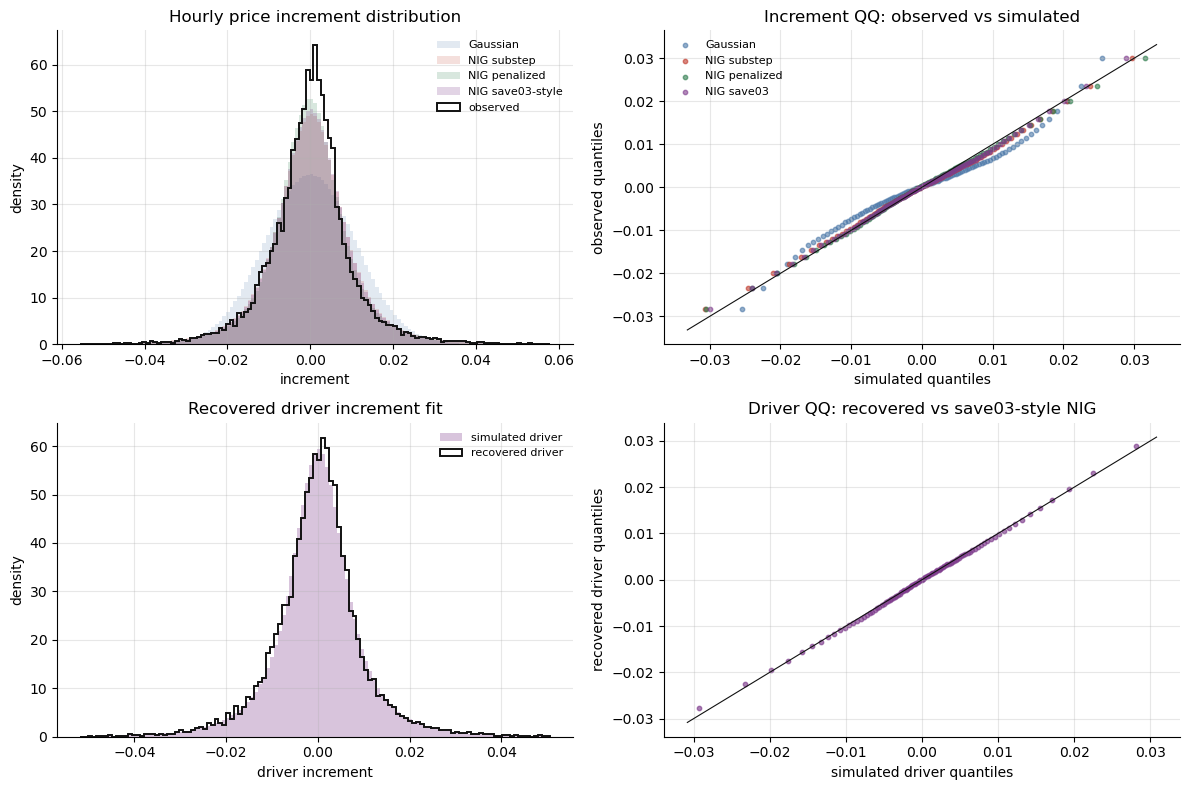

Saved: price_nig_save03style_distributions.png


In [141]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
probs = np.linspace(0.01, 0.99, 99)

ax = axes[0, 0]
bins_inc = np.linspace(
    min(np.quantile(obs_increments, 0.001), np.quantile(sim_increments, 0.001),
        np.quantile(nig_increments, 0.001), np.quantile(nig_pen_increments, 0.001),
        np.quantile(nig_save03_increments, 0.001)),
    max(np.quantile(obs_increments, 0.999), np.quantile(sim_increments, 0.999),
        np.quantile(nig_increments, 0.999), np.quantile(nig_pen_increments, 0.999),
        np.quantile(nig_save03_increments, 0.999)),
    130,
)
ax.hist(sim_increments.ravel(), bins=bins_inc, density=True, color='#4c78a8', alpha=0.16, label='Gaussian')
ax.hist(nig_increments.ravel(), bins=bins_inc, density=True, color='#c0392b', alpha=0.16, label='NIG substep')
ax.hist(nig_pen_increments.ravel(), bins=bins_inc, density=True, color='#2c7a4b', alpha=0.18, label='NIG penalized')
ax.hist(nig_save03_increments.ravel(), bins=bins_inc, density=True, color='#7f3c8d', alpha=0.22, label='NIG save03-style')
ax.hist(obs_increments, bins=bins_inc, density=True, histtype='step', color='#111111', lw=1.4, label='observed')
ax.set_title('Hourly price increment distribution')
ax.set_xlabel('increment')
ax.set_ylabel('density')
ax.legend(frameon=False, fontsize=8)

ax = axes[0, 1]
obs_q = np.quantile(obs_increments, probs)
series_q = {
    'Gaussian': (np.quantile(sim_increments.ravel(), probs), '#4c78a8'),
    'NIG substep': (np.quantile(nig_increments.ravel(), probs), '#c0392b'),
    'NIG penalized': (np.quantile(nig_pen_increments.ravel(), probs), '#2c7a4b'),
    'NIG save03': (np.quantile(nig_save03_increments.ravel(), probs), '#7f3c8d'),
}
lim = max([abs(obs_q).max()] + [abs(v[0]).max() for v in series_q.values()]) * 1.05
for label, (qv, color) in series_q.items():
    ax.scatter(qv, obs_q, s=10, color=color, alpha=0.6, label=label)
ax.plot([-lim, lim], [-lim, lim], color='#111111', lw=0.8)
ax.set_title('Increment QQ: observed vs simulated')
ax.set_xlabel('simulated quantiles')
ax.set_ylabel('observed quantiles')
ax.legend(frameon=False, fontsize=8)

ax = axes[1, 0]
bins_driver = np.linspace(
    min(np.quantile(dL_fit, 0.001), np.quantile(nig_save03_driver, 0.001)),
    max(np.quantile(dL_fit, 0.999), np.quantile(nig_save03_driver, 0.999)),
    120,
)
ax.hist(nig_save03_driver.ravel(), bins=bins_driver, density=True, color='#7f3c8d', alpha=0.30, label='simulated driver')
ax.hist(dL_fit, bins=bins_driver, density=True, histtype='step', color='#111111', lw=1.4, label='recovered driver')
ax.set_title('Recovered driver increment fit')
ax.set_xlabel('driver increment')
ax.set_ylabel('density')
ax.legend(frameon=False, fontsize=8)

ax = axes[1, 1]
obs_driver_q = np.quantile(dL_fit, probs)
sim_driver_q = np.quantile(nig_save03_driver.ravel(), probs)
lim = max(abs(obs_driver_q).max(), abs(sim_driver_q).max()) * 1.05
ax.scatter(sim_driver_q, obs_driver_q, s=10, color='#7f3c8d', alpha=0.65)
ax.plot([-lim, lim], [-lim, lim], color='#111111', lw=0.8)
ax.set_title('Driver QQ: recovered vs save03-style NIG')
ax.set_xlabel('simulated driver quantiles')
ax.set_ylabel('recovered driver quantiles')

plt.tight_layout()
fig_path = CODE / 'notebooks' / 'figures' / 'price_nig_save03style_distributions.png'
plt.savefig(fig_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path.name}")
